In [45]:
# import numpy as np
# import matplotlib.pyplot as plt


# def solve_el_fft(eta, N=256, alpha=1.0, tol=1e-6, max_iter=1000):
#     """
#     Solve -π U''(X) + √2 eta^2 sin(X + 2π√2 U(X)) = 0 
#     with periodic boundary and ∫_0^2π U dX = 0.
#     Returns array U(X) of length N.
#     """
#     # Initialize the grid
#     X = np.linspace(0.0, 2.0 * np.pi, N, endpoint=False)
#     U = np.zeros(N)  # Initial guess for U(satisfie mean 0 condition)

#     # Precompute constants factors
#     const = np.sqrt(2) * (eta**2) / np.pi

#     # Fourier wavenumbers in radians per unit length
#     dx = 2.0 * np.pi / N  #grid spacing
#     k = 2.0 * np.pi * np.fft.fftfreq(N, d=dx)  # shape (N,)
#     theta = k * dx  # dimensionless 2πk/N

#     # FD Fourier symbols
#     D1 = 1j * np.sin(theta) / dx  # i·sin(k dx)/dx
#     D2 = -4.0 * np.sin(theta / 2.0)**2 / dx**2  # -4 sin²(k dx/2)/dx²

#     # ------- fixed‑point (Picard) iteration -------------------------------
#     # compute U_new from U_old by solving U_new'' = const * sin(X + 2π√2 U(X))
#     for iteration in range(max_iter):
#         # Compute the right-hand side in Fourier space
#         rhs = const * np.sin(X + 2.0 * np.pi * np.sqrt(2) * U)
#         rhs_hat = np.fft.fft(rhs)
#         # Express the left-hand side in Fourier space using finite differences and fourier transform
#         lhs_hat = D2 * np.fft.fft(U)

In [46]:
import numpy as np

In [47]:
def fd_symbol(N, dx, fd_order=2):
    """
    Return λ_fd[k]  =  discrete symbol of  -∂xx  (positive-definite)
                      on a uniform 2π-periodic grid.
    fd_order = 2 -> 4 sin²(θ/2)/dx²   (3-point)
    fd_order = 4 -> (5/2 − 8/3 cosθ + 1/6 cos2θ)/dx²   (5-point)
    """
    k_phys = 2.0 * np.pi * np.fft.fftfreq(N, d=dx)
    theta  = k_phys * dx
    if fd_order == 2:
        lam = 4.0 * np.sin(theta/2.0)**2 / dx**2          # λ₂(θ)
    elif fd_order == 4:
        lam = (2.5 - (8.0/3.0)*np.cos(theta)
                     + (1.0/6.0)*np.cos(2.0*theta)) / dx**2  # λ₄(θ)
    else:
        raise ValueError("fd_order must be 2 or 4")
    lam[0] = 0.0      # enforce mean-zero null-space
    return lam

In [48]:
def solve_relaxation(eta, N=512, alpha=0.3, fd_order=2,
                     tol=1e-8, max_iter=10_000):
    """Fixed-point Picard iteration with relaxation α."""
    L  = 2*np.pi
    x  = np.linspace(0, L, N, endpoint=False)
    dx = x[1]-x[0]
    lam = fd_symbol(N, dx, fd_order)       # λ_fd(k)  (positive)
    U   = np.zeros(N)

    for k in range(max_iter):
        U_old = U.copy()
        f_val = -(np.sqrt(2)*eta**2/np.pi)*np.sin(x + 2*np.pi*np.sqrt(2)*U)
        f_val -= f_val.mean()              # solvability

        # Poisson solve:  λ_fd * W_hat = f_hat  ⇒  W_hat = f_hat/λ_fd
        f_hat   = np.fft.fft(f_val)
        W_hat   = np.zeros_like(f_hat)
        nz_idx  = lam > 0                  # skip k=0
        W_hat[nz_idx] = f_hat[nz_idx] / lam[nz_idx]
        W       = np.real(np.fft.ifft(W_hat))

        U       = (1-alpha)*U + alpha*W
        U      -= U.mean()                 # enforce ⟨U⟩=0
        relerr  = np.linalg.norm(U-U_old)/max(1e-30,np.linalg.norm(U_old))
        if relerr < tol:
            return U, True, k+1
    return U, False, max_iter

In [ ]:
def solve_virtual_time(eta,
                       N=512,
                       h=0.4,
                       fd_order=2,
                       tol=1e-8,
                       max_iter=10_000):
    """Semi-implicit Euler:  (I - h∇²)^{-1}(U + h f(U))."""
    L = 2 * np.pi
    x = np.linspace(0, L, N, endpoint=False)
    dx = x[1] - x[0]
    lam = fd_symbol(N, dx, fd_order)  # λ_fd ≥ 0
    denom = 1.0 + h * lam  # (I - h∇²) = (I + h(-Δ)) = (I + h λ_fd) in Fourier
    denom[0] = 1.0  # but we will zero k=0 anyway
    U = np.zeros(N)

    for k in range(max_iter):
        U_old = U.copy()
        f_val = -(np.sqrt(2) * eta**2 / np.pi) * np.sin(x + 2 * np.pi *
                                                        np.sqrt(2) * U)
        R = U + h * f_val
        R -= R.mean()  # keep solvability
        R_hat = np.fft.fft(R)
        U_hat = np.zeros_like(R_hat)
        nz_idx = lam > 0
        U_hat[nz_idx] = R_hat[nz_idx] / denom[nz_idx]
        U = np.real(np.fft.ifft(U_hat))
        # mean already zero by construction
        relerr = np.linalg.norm(U - U_old) / max(1e-30, np.linalg.norm(U_old))
        if relerr < tol:
            return U, True, k + 1
    return U, False, max_iter

[Relaxation] converged=True  iterations=47
[Pseudo-time] converged=True  iterations=16
L2-norm difference between solutions = 6.641e-08


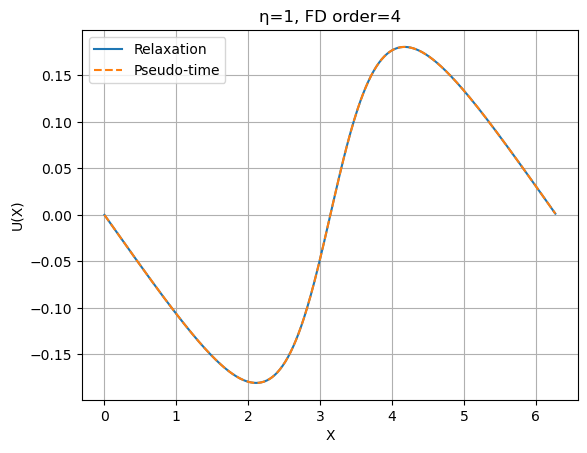

In [50]:
import matplotlib.pyplot as plt

def main():
    eta = 1
    N   = 512
    # ---- parameters you want to test ----
    alpha = 0.3          # relaxation
    h     = 0.4          # pseudo-time
    fd_order = 4         # 2  or  4
    # -------------------------------------

    U_rel, ok_rel, nit_rel = solve_relaxation(eta, N=N, alpha=alpha,
                                              fd_order=fd_order)
    U_tim, ok_tim, nit_tim = solve_virtual_time(eta, N=N, h=h,
                                                fd_order=fd_order)

    print(f"[Relaxation] converged={ok_rel}  iterations={nit_rel}")
    print(f"[Pseudo-time] converged={ok_tim}  iterations={nit_tim}")
    if not ok_rel:
        print("WARNING  relaxation method did not converge.")
    if not ok_tim:
        print("WARNING  pseudo-time method did not converge.")

    diff = np.linalg.norm(U_rel - U_tim)
    print(f"L2-norm difference between solutions = {diff:.3e}")

    x = np.linspace(0, 2*np.pi, N, endpoint=False)
    plt.plot(x, U_rel, label="Relaxation")
    plt.plot(x, U_tim, "--", label="Pseudo-time")
    plt.title(rf"η={eta}, FD order={fd_order}")
    plt.xlabel("X"); plt.ylabel("U(X)")
    plt.legend(); plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()